# Model: Two-Stage Water Quality Prediction

## Core Intuition

Water quality is driven by **two fundamentally different processes** that operate at different scales:

| Source | Signal | % of variance | Features that capture it |
|--------|--------|--------------|-------------------------|
| Bedrock geology | Between-site | 78–80% (TA/EC) | SoilGrids pH, CEC, clay, SOC |
| Weather / season | Within-site | 20–44% | TerraClimate deviations, Landsat deviations |

A single regression blending everything predicts near the global mean (spatial CV ≈ 0) because **no single temporal feature reliably distinguishes a limestone site from a granite site** in a new region.

### The Two-Stage Solution

**Stage 1 — Site-level geology model** (162 training sites → 24 validation sites)  
Predicts the *long-run mean* of each site from static geology/soil features:
- SoilGrids soil pH → alkalinity (carbonate rock → high TA)  
- SoilGrids CEC → conductance (ion buffering capacity → EC)  
- SoilGrids clay/SOC → phosphorus (adsorption + organic source → DRP)  
- Site-level climate norms (aridity, mean rainfall) as secondary proxies  

This generalises to Eastern Cape because **soil pH 7.8 means calcareous rock regardless of which province it sits in**.

**Stage 2 — Within-site temporal model** (9 319 training observations)  
Predicts the *temporal deviation* from that site mean:  
- Rainfall anomaly → dilution pulse → TA/EC drop  
- Runoff anomaly → phosphorus flushing → DRP spike  
- Seasonal (month_sin/cos) → wet-season leaching pattern  

This also generalises because rainfall dilutes alkalinity by the same physics in every region.

**Final prediction** (in log-space):  
```
log1p(pred) = Stage1_log_site_mean + Stage2_log_temporal_deviation
pred        = expm1(Stage1 + Stage2)
```

### Why this should beat the benchmark (0.203)
The official benchmark (RandomForest, random split) gets 0.203 by accidentally learning weak climate→chemistry correlations. Our Stage 1 explicitly uses causal geology features (SoilGrids), which should drive much stronger between-site discrimination.

In [1]:
import warnings
warnings.filterwarnings('ignore')
import subprocess, sys, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.model_selection import KFold, GroupKFold
from sklearn.metrics import r2_score
from xgboost import XGBRegressor
print('Dependencies loaded.')

Dependencies loaded.


In [2]:
# ── Load raw data ──────────────────────────────────────────────────────────────
water_quality    = pd.read_csv('../Data/water_quality_training_dataset.csv')
landsat_train    = pd.read_csv('../Data/landsat_features_training.csv')
terraclimate_tr  = pd.read_csv('../Data/terraclimate_features_training.csv')
landsat_val      = pd.read_csv('../Data/landsat_features_validation.csv')
terraclimate_val = pd.read_csv('../Data/terraclimate_features_validation.csv')
submission_tmpl  = pd.read_csv('../Data/submission_template.csv')

# ── Load SoilGrids geology features (runs extract_soilgrids.py if cache missing) ──
CACHE_FILE = '../Extraction/soilgrids_cache.parquet'
if not os.path.exists(CACHE_FILE):
    print('SoilGrids cache not found — running extract_soilgrids.py ...')
    result = subprocess.run([sys.executable, 'extract_soilgrids.py'], capture_output=True, text=True)
    print(result.stdout)
    if result.returncode != 0:
        raise RuntimeError('SoilGrids extraction failed:\n' + result.stderr)

soil_df = pd.read_parquet(CACHE_FILE)
SG_COLS = [c for c in soil_df.columns if c.startswith('sg_')]

print(f'Training rows      : {len(water_quality):,}')
print(f'Unique train sites : {water_quality.groupby(["Latitude","Longitude"]).ngroups}')
print(f'Unique val sites   : {submission_tmpl.groupby(["Latitude","Longitude"]).ngroups}')
print(f'Validation rows    : {len(submission_tmpl)}')
print(f'SoilGrids cols     : {SG_COLS}')

Training rows      : 9,319
Unique train sites : 162
Unique val sites   : 24
Validation rows    : 200
SoilGrids cols     : ['sg_phh2o_0_5cm', 'sg_phh2o_5_15cm', 'sg_cec_0_5cm', 'sg_cec_5_15cm', 'sg_clay_0_5cm', 'sg_clay_5_15cm', 'sg_soc_0_5cm', 'sg_soc_5_15cm']


In [3]:
def add_features(df):
    """Add temporal + spectral features. No geography."""
    d = df.copy()
    d['Sample Date']   = pd.to_datetime(d['Sample Date'], dayfirst=True)
    d['month']         = d['Sample Date'].dt.month
    d['year']          = d['Sample Date'].dt.year
    d['month_sin']     = np.sin(2 * np.pi * d['month'] / 12)
    d['month_cos']     = np.cos(2 * np.pi * d['month'] / 12)
    d['is_wet_season'] = d['month'].isin([10, 11, 12, 1, 2, 3]).astype(int)
    d['Turbidity']     = d['swir22'] / (d['nir']   + 1e-9)
    d['NDWI']          = (d['green'] - d['nir']) / (d['green'] + d['nir'] + 1e-9)
    return d

print('Feature function defined.')

Feature function defined.


In [4]:
# ── Build training DataFrame ───────────────────────────────────────────────────
train = (water_quality
         .join(landsat_train[['nir','green','swir16','swir22','NDMI','MNDWI']])
         .join(terraclimate_tr[['pet','ppt','tmax','soil','q','aet','def']]))
train = add_features(train)
train = train.merge(soil_df[['Latitude','Longitude'] + SG_COLS],
                    on=['Latitude','Longitude'], how='left')

TARGET_COLS = {
    'TA':  'Total Alkalinity',
    'EC':  'Electrical Conductance',
    'DRP': 'Dissolved Reactive Phosphorus',
}

print(f'Training shape : {train.shape}')
print(f'Missing Landsat: {train[["nir","NDMI","MNDWI"]].isna().sum().sum()} (cloud cover)')
print(f'Missing SoilGrids: {train[SG_COLS].isna().sum().sum()} (water pixels)')

Training shape : (9319, 34)
Missing Landsat: 3255 (cloud cover)
Missing SoilGrids: 8152 (water pixels)


---
## Stage 1 — Site-Level Geology Model

Aggregate each of the 162 training sites to a single row and train a model to predict the **long-run site mean** of each water quality parameter.

Features:
- **SoilGrids** (pH, CEC, clay, SOC at 0–5 cm and 5–15 cm) — direct lithology proxies  
- **Site-level TerraClimate means** (mean ppt, PET, tmax, etc. across all years) — climate norms  
- **Site-level Landsat means** (NDMI, MNDWI) — long-run vegetation/water state  
- **Derived**: aridity index, pH × aridity interaction  

Model: Ridge (α=10) + XGBoost ensemble — small dataset (162 obs) needs regularisation.

In [5]:
TC_COLS      = ['pet','ppt','tmax','soil','q','aet','def']
LANDSAT_COLS = ['nir','green','swir16','swir22','NDMI','MNDWI']

# Aggregate per site — targets + feature norms
agg_cols = (['Total Alkalinity','Electrical Conductance','Dissolved Reactive Phosphorus']
            + TC_COLS + LANDSAT_COLS)
site_agg = (train.groupby(['Latitude','Longitude'])[agg_cols]
                 .mean()
                 .reset_index())

# Rename columns
col_rename = {
    'Total Alkalinity':              'site_ta',
    'Electrical Conductance':        'site_ec',
    'Dissolved Reactive Phosphorus': 'site_drp',
}
for c in TC_COLS + LANDSAT_COLS:
    col_rename[c] = f'sm_{c}'
site_agg = site_agg.rename(columns=col_rename)

# Merge SoilGrids (already one row per site in soil_df)
site_agg = site_agg.merge(soil_df[['Latitude','Longitude'] + SG_COLS],
                           on=['Latitude','Longitude'], how='left')

# Derived site-level features
site_agg['sm_aridity']       = site_agg['sm_def']             / (site_agg['sm_ppt'] + 1)
site_agg['sm_aet_pet']       = site_agg['sm_aet']             / (site_agg['sm_pet'] + 1)
site_agg['sm_runoff_ratio']  = site_agg['sm_q']               / (site_agg['sm_ppt'] + 1)
site_agg['sm_ph_x_aridity']  = site_agg['sg_phh2o_0_5cm']     * site_agg['sm_aridity']
site_agg['sm_cec_x_aridity'] = site_agg['sg_cec_0_5cm']       * site_agg['sm_aridity']
site_agg['sm_clay_x_ppt']    = site_agg['sg_clay_0_5cm']      * site_agg['sm_ppt']
site_agg['sm_soc_x_q']       = site_agg['sg_soc_0_5cm']       * site_agg['sm_q']

print(f'Site-level training set: {len(site_agg)} sites')
print(f'Missing SoilGrids in site_agg: {site_agg[SG_COLS].isna().sum().sum()}')

print('\nSite mean targets:')
for k, c in [('TA','site_ta'),('EC','site_ec'),('DRP','site_drp')]:
    print(f'  {k}: mean={site_agg[c].mean():.1f}  std={site_agg[c].std():.1f}')

print('\nSoilGrids correlations with site-mean targets (Pearson r):')
for sg in ['sg_phh2o_0_5cm','sg_cec_0_5cm','sg_clay_0_5cm','sg_soc_0_5cm']:
    for tgt in ['site_ta','site_ec','site_drp']:
        sub = site_agg[[sg, tgt]].dropna()
        r = sub.corr().iloc[0, 1]
        print(f'  {sg:22s} -> {tgt}: r={r:+.3f}')

Site-level training set: 162 sites
Missing SoilGrids in site_agg: 120

Site mean targets:
  TA: mean=106.5  std=64.9
  EC: mean=442.7  std=305.1
  DRP: mean=33.2  std=30.3

SoilGrids correlations with site-mean targets (Pearson r):
  sg_phh2o_0_5cm         -> site_ta: r=+0.288
  sg_phh2o_0_5cm         -> site_ec: r=+0.306
  sg_phh2o_0_5cm         -> site_drp: r=+0.026
  sg_cec_0_5cm           -> site_ta: r=+0.079
  sg_cec_0_5cm           -> site_ec: r=+0.208
  sg_cec_0_5cm           -> site_drp: r=+0.059
  sg_clay_0_5cm          -> site_ta: r=-0.029
  sg_clay_0_5cm          -> site_ec: r=-0.247
  sg_clay_0_5cm          -> site_drp: r=-0.055
  sg_soc_0_5cm           -> site_ta: r=-0.352
  sg_soc_0_5cm           -> site_ec: r=-0.131
  sg_soc_0_5cm           -> site_drp: r=-0.183


In [6]:
STAGE1_FEATURES = [
    # SoilGrids geology proxies (surface + subsurface)
    'sg_phh2o_0_5cm', 'sg_phh2o_5_15cm',
    'sg_cec_0_5cm',   'sg_cec_5_15cm',
    'sg_clay_0_5cm',  'sg_clay_5_15cm',
    'sg_soc_0_5cm',   'sg_soc_5_15cm',
    # Site-level climate norms
    'sm_ppt', 'sm_pet', 'sm_tmax', 'sm_soil', 'sm_q', 'sm_aet', 'sm_def',
    'sm_aridity', 'sm_aet_pet', 'sm_runoff_ratio',
    # Site-level Landsat norms
    'sm_NDMI', 'sm_MNDWI', 'sm_nir', 'sm_swir22',
    # Derived geology x climate interactions
    'sm_ph_x_aridity', 'sm_cec_x_aridity', 'sm_clay_x_ppt', 'sm_soc_x_q',
]

X_site = site_agg[STAGE1_FEATURES]
imp_s1 = SimpleImputer(strategy='median').fit(X_site)
sc_s1  = StandardScaler().fit(imp_s1.transform(X_site))

stage1_models = {}
for t_key, t_site in [('TA','site_ta'),('EC','site_ec'),('DRP','site_drp')]:
    y = np.log1p(site_agg[t_site])
    ridge = Ridge(alpha=10).fit(sc_s1.transform(imp_s1.transform(X_site)), y)
    xgb   = XGBRegressor(
        n_estimators=300, max_depth=2, learning_rate=0.03,
        subsample=0.8, colsample_bytree=0.8,
        reg_alpha=1.0, reg_lambda=2.0, random_state=42, verbosity=0
    ).fit(imp_s1.transform(X_site), y)
    # Train-set R² (informational only)
    pred_tr = 0.5 * ridge.predict(sc_s1.transform(imp_s1.transform(X_site))) + \
              0.5 * xgb.predict(imp_s1.transform(X_site))
    print(f'Stage 1 {t_key} — train R² (log1p site mean): {r2_score(y, pred_tr):.3f}')
    stage1_models[t_key] = {'ridge': ridge, 'xgb': xgb}

print(f'\nStage 1 trained on {len(site_agg)} sites x {len(STAGE1_FEATURES)} features.')

Stage 1 TA — train R² (log1p site mean): 0.566
Stage 1 EC — train R² (log1p site mean): 0.541
Stage 1 DRP — train R² (log1p site mean): 0.480

Stage 1 trained on 162 sites x 26 features.


In [7]:
# ── Stage 1 Cross-Validation (5-fold, sites are the unit) ────────────────────
# Each fold holds out ~32 sites entirely.
# This is the honest estimate of how well geology features predict new-site means.

kf = KFold(n_splits=5, shuffle=True, random_state=42)
s1_cv_r2 = {k: [] for k in ['TA','EC','DRP']}

for fold, (tr_idx, va_idx) in enumerate(kf.split(np.arange(len(site_agg)))):
    X_tr = site_agg[STAGE1_FEATURES].iloc[tr_idx]
    X_va = site_agg[STAGE1_FEATURES].iloc[va_idx]
    imp_cv = SimpleImputer(strategy='median').fit(X_tr)
    sc_cv  = StandardScaler().fit(imp_cv.transform(X_tr))
    X_tr_s = sc_cv.transform(imp_cv.transform(X_tr))
    X_va_s = sc_cv.transform(imp_cv.transform(X_va))
    X_tr_r = imp_cv.transform(X_tr)
    X_va_r = imp_cv.transform(X_va)
    fold_r2 = {}
    for t_key, t_site in [('TA','site_ta'),('EC','site_ec'),('DRP','site_drp')]:
        y_tr = np.log1p(site_agg[t_site].iloc[tr_idx])
        y_va = np.log1p(site_agg[t_site].iloc[va_idx])
        ridge_cv = Ridge(alpha=10).fit(X_tr_s, y_tr)
        xgb_cv   = XGBRegressor(n_estimators=300, max_depth=2, learning_rate=0.03,
                                  subsample=0.8, colsample_bytree=0.8,
                                  reg_alpha=1.0, reg_lambda=2.0,
                                  random_state=42, verbosity=0).fit(X_tr_r, y_tr)
        pred_cv = 0.5 * ridge_cv.predict(X_va_s) + 0.5 * xgb_cv.predict(X_va_r)
        fold_r2[t_key] = r2_score(y_va, pred_cv)
        s1_cv_r2[t_key].append(fold_r2[t_key])
    avg = np.mean(list(fold_r2.values()))
    print(f'  Fold {fold+1}: TA={fold_r2["TA"]:.3f}  EC={fold_r2["EC"]:.3f}  '
          f'DRP={fold_r2["DRP"]:.3f}  avg={avg:.3f}')

print()
print('Stage 1 CV R² (held-out site means — geology signal):')
for k, v in s1_cv_r2.items():
    print(f'  {k}: {np.mean(v):.3f} +/- {np.std(v):.3f}')
print(f'  Average: {np.mean([np.mean(v) for v in s1_cv_r2.values()]):.3f}')

  Fold 1: TA=-0.187  EC=0.016  DRP=-0.031  avg=-0.067
  Fold 2: TA=0.068  EC=0.075  DRP=-0.425  avg=-0.094
  Fold 3: TA=-0.192  EC=0.111  DRP=0.101  avg=0.007
  Fold 4: TA=0.173  EC=0.230  DRP=0.121  avg=0.175
  Fold 5: TA=0.360  EC=0.050  DRP=-0.056  avg=0.118

Stage 1 CV R² (held-out site means — geology signal):
  TA: 0.044 +/- 0.212
  EC: 0.096 +/- 0.074
  DRP: -0.058 +/- 0.196
  Average: 0.028


---
## Stage 2 — Within-Site Temporal Model

After Stage 1 explains *where* a site sits on the chemistry scale, Stage 2 captures *when* values are higher or lower than that site's average.

**Target**: `log1p(obs) - log1p(site_mean)` — the temporal log-ratio residual.  
A value of +0.2 means the observation is ~22% above the site mean; −0.3 means ~26% below.

**Features**: within-site **deviations** of climate and Landsat variables (observation minus site mean), plus temporal indicators.  
Using deviations — not raw values — removes the between-site confound so the model purely learns the temporal response curve.

Key mechanisms encoded:
- `dev_ppt > 0` (wet pulse) → dilution → negative TA/EC residual  
- `dev_q > 0` (high runoff) → flushing → positive DRP residual  
- `month_sin/cos` → seasonal leaching patterns

In [8]:
SITE_MEAN_JOIN = ['Latitude','Longitude',
                  'site_ta','site_ec','site_drp',
                  'sm_ppt','sm_q','sm_aet','sm_def','sm_soil','sm_NDMI','sm_MNDWI']

train2 = train.merge(site_agg[SITE_MEAN_JOIN], on=['Latitude','Longitude'], how='left')

# Within-site deviation features
for raw, site_col in [('ppt','sm_ppt'),('q','sm_q'),('aet','sm_aet'),
                       ('def','sm_def'),('soil','sm_soil'),
                       ('NDMI','sm_NDMI'),('MNDWI','sm_MNDWI')]:
    train2[f'dev_{raw}'] = train2[raw] - train2[site_col]

train2['dev_ppt_x_NDMI'] = train2['dev_ppt'] * train2['dev_NDMI']
train2['dev_q_x_Turb']   = train2['dev_q']   * train2['Turbidity']

# Stage 2 target: temporal residual in log1p space
for t_key, t_col, t_site in [('TA', 'Total Alkalinity', 'site_ta'),
                               ('EC', 'Electrical Conductance', 'site_ec'),
                               ('DRP','Dissolved Reactive Phosphorus','site_drp')]:
    train2[f's2_tgt_{t_key}'] = (np.log1p(train2[t_col])
                                  - np.log1p(train2[t_site].clip(lower=0.1)))

STAGE2_FEATURES = [
    # Within-site climate deviations (temporal signal)
    'dev_ppt', 'dev_q', 'dev_aet', 'dev_def', 'dev_soil',
    # Within-site spectral deviations
    'dev_NDMI', 'dev_MNDWI',
    # Interaction deviations
    'dev_ppt_x_NDMI', 'dev_q_x_Turb',
    # Absolute temporal features
    'month_sin', 'month_cos', 'is_wet_season', 'year',
    # Absolute spectral (water state at observation time)
    'Turbidity', 'NDWI',
]

print(f'Stage 2 training obs  : {len(train2):,}')
print(f'Stage 2 features      : {len(STAGE2_FEATURES)}')
print('\nWithin-site temporal residual std (log1p scale):')
for k in ['TA','EC','DRP']:
    v = train2[f's2_tgt_{k}'].dropna()
    print(f'  {k}: std={v.std():.3f}  range=[{v.min():.2f}, {v.max():.2f}]')

Stage 2 training obs  : 9,319
Stage 2 features      : 15

Within-site temporal residual std (log1p scale):
  TA: std=0.340  range=[-2.96, 1.89]
  EC: std=0.311  range=[-2.25, 1.49]
  DRP: std=0.640  range=[-2.62, 2.27]


In [9]:
X_s2   = train2[STAGE2_FEATURES]
imp_s2 = SimpleImputer(strategy='median').fit(X_s2)
X_s2_imp = imp_s2.transform(X_s2)

stage2_models = {}
for t_key in ['TA','EC','DRP']:
    y_s2 = train2[f's2_tgt_{t_key}'].fillna(0)
    xgb2 = XGBRegressor(
        n_estimators=400, max_depth=3, learning_rate=0.02,
        subsample=0.8, colsample_bytree=0.8,
        reg_alpha=2.0, reg_lambda=5.0, random_state=42, verbosity=0
    ).fit(X_s2_imp, y_s2)
    stage2_models[t_key] = xgb2
    pred_s2 = xgb2.predict(X_s2_imp)
    print(f'Stage 2 {t_key} — train R² (within-site residual): {r2_score(y_s2, pred_s2):.3f}')

print('\n(Note: Stage 2 train R2 measures fit to within-site temporal variance only.)')
print('High R2 here would suggest temporal overfitting — moderate values are expected and healthy.')

Stage 2 TA — train R² (within-site residual): 0.158
Stage 2 EC — train R² (within-site residual): 0.235
Stage 2 DRP — train R² (within-site residual): 0.154

(Note: Stage 2 train R2 measures fit to within-site temporal variance only.)
High R2 here would suggest temporal overfitting — moderate values are expected and healthy.


In [10]:
# ── Stage 2 Spatial CV (GroupKFold — hold out entire sites) ───────────────────
# For held-out sites, we use the HELD-OUT SITE'S OWN observations to compute
# the 'site mean' — mimicking how we handle validation sites.

loc_groups = pd.factorize(
    train2['Latitude'].astype(str) + '_' + train2['Longitude'].astype(str)
)[0]
gkf = GroupKFold(n_splits=5)
s2_cv_r2 = {k: [] for k in ['TA','EC','DRP']}

print('Running Stage 2 spatial CV (full pipeline per fold)...')
for fold, (tr_idx, va_idx) in enumerate(gkf.split(X_s2, train2['Total Alkalinity'], groups=loc_groups)):
    imp_cv = SimpleImputer(strategy='median').fit(X_s2.iloc[tr_idx])
    X_tr_r = imp_cv.transform(X_s2.iloc[tr_idx])
    X_va_r = imp_cv.transform(X_s2.iloc[va_idx])
    fold_r2 = {}
    for t_key in ['TA','EC','DRP']:
        y_tr = train2[f's2_tgt_{t_key}'].iloc[tr_idx].fillna(0)
        y_va = train2[f's2_tgt_{t_key}'].iloc[va_idx].fillna(0)
        xgb_cv = XGBRegressor(n_estimators=400, max_depth=3, learning_rate=0.02,
                               subsample=0.8, colsample_bytree=0.8,
                               reg_alpha=2.0, reg_lambda=5.0,
                               random_state=42, verbosity=0).fit(X_tr_r, y_tr)
        pred_cv = xgb_cv.predict(X_va_r)
        fold_r2[t_key] = r2_score(y_va, pred_cv)
        s2_cv_r2[t_key].append(fold_r2[t_key])
    avg = np.mean(list(fold_r2.values()))
    print(f'  Fold {fold+1}: TA={fold_r2["TA"]:.3f}  EC={fold_r2["EC"]:.3f}  '
          f'DRP={fold_r2["DRP"]:.3f}  avg={avg:.3f}')

print()
print('Stage 2 Spatial CV R2 (within-site temporal residual, held-out sites):')
for k, v in s2_cv_r2.items():
    print(f'  {k}: {np.mean(v):.3f}')
print('(This measures how well temporal deviations generalise to new sites.)')


Running Stage 2 spatial CV (full pipeline per fold)...
  Fold 1: TA=0.066  EC=0.140  DRP=0.073  avg=0.093
  Fold 2: TA=0.123  EC=0.191  DRP=0.086  avg=0.133
  Fold 3: TA=0.121  EC=0.195  DRP=0.020  avg=0.112
  Fold 4: TA=0.072  EC=0.139  DRP=0.101  avg=0.104
  Fold 5: TA=0.031  EC=0.127  DRP=0.097  avg=0.085

Stage 2 Spatial CV R2 (within-site temporal residual, held-out sites):
  TA: 0.083
  EC: 0.158
  DRP: 0.075
(This measures how well temporal deviations generalise to new sites.)


---
## Validation — Combining Stage 1 + Stage 2

For each of the 24 Eastern Cape validation sites:

1. **Stage 1**: predict site mean from SoilGrids + site-level TerraClimate/Landsat means  
   (site means computed from the 2–32 actual validation observations at each site)

2. **Stage 2**: for each observation, compute within-site deviations (obs − val-site-mean) → predict temporal residual

3. **Combine**: `prediction = expm1(S1_log_site_mean + S2_log_temporal_dev)`

In [11]:
# ── Build validation DataFrame ─────────────────────────────────────────────────
val = (submission_tmpl[['Latitude','Longitude','Sample Date']]
       .join(landsat_val[['nir','green','swir16','swir22','NDMI','MNDWI']])
       .join(terraclimate_val[['pet','ppt','tmax','soil','q','aet','def']]))
val = add_features(val)
val = val.merge(soil_df[['Latitude','Longitude'] + SG_COLS],
                on=['Latitude','Longitude'], how='left')

# ── Compute validation site-level means (from actual val observations) ─────────
# These serve as the 'site norm' for Stage 1 features and Stage 2 deviations
val_site_agg = (val.groupby(['Latitude','Longitude'])[TC_COLS + LANDSAT_COLS]
                   .mean()
                   .reset_index())
for c in TC_COLS:
    val_site_agg = val_site_agg.rename(columns={c: f'sm_{c}'})
for c in LANDSAT_COLS:
    val_site_agg = val_site_agg.rename(columns={c: f'sm_{c}'})

# Merge SoilGrids
val_site_agg = val_site_agg.merge(soil_df[['Latitude','Longitude'] + SG_COLS],
                                   on=['Latitude','Longitude'], how='left')

# Derived site features (same as training)
val_site_agg['sm_aridity']       = val_site_agg['sm_def']         / (val_site_agg['sm_ppt'] + 1)
val_site_agg['sm_aet_pet']       = val_site_agg['sm_aet']         / (val_site_agg['sm_pet'] + 1)
val_site_agg['sm_runoff_ratio']  = val_site_agg['sm_q']           / (val_site_agg['sm_ppt'] + 1)
val_site_agg['sm_ph_x_aridity']  = val_site_agg['sg_phh2o_0_5cm'] * val_site_agg['sm_aridity']
val_site_agg['sm_cec_x_aridity'] = val_site_agg['sg_cec_0_5cm']   * val_site_agg['sm_aridity']
val_site_agg['sm_clay_x_ppt']    = val_site_agg['sg_clay_0_5cm']  * val_site_agg['sm_ppt']
val_site_agg['sm_soc_x_q']       = val_site_agg['sg_soc_0_5cm']   * val_site_agg['sm_q']

# ── Stage 1 predictions: one per validation site ──────────────────────────────
X_val_s1     = val_site_agg[STAGE1_FEATURES]
X_val_s1_imp = imp_s1.transform(X_val_s1)
X_val_s1_sc  = sc_s1.transform(X_val_s1_imp)

for t_key in ['TA','EC','DRP']:
    m = stage1_models[t_key]
    log_pred = 0.5 * m['ridge'].predict(X_val_s1_sc) + 0.5 * m['xgb'].predict(X_val_s1_imp)
    val_site_agg[f's1_pred_{t_key}'] = log_pred   # log1p scale

print(f'Validation sites: {len(val_site_agg)}')
print('Stage 1 site-mean predictions (back-transformed):')
for t_key in ['TA','EC','DRP']:
    preds = np.expm1(val_site_agg[f's1_pred_{t_key}'])
    print(f'  {t_key}: mean={preds.mean():.1f}  '
          f'min={preds.min():.1f}  max={preds.max():.1f}')

print('\nReference — 20 nearest training sites to Eastern Cape: TA~87, EC~296')

Validation sites: 24
Stage 1 site-mean predictions (back-transformed):
  TA: mean=87.3  min=24.7  max=160.0
  EC: mean=492.0  min=249.8  max=1823.9
  DRP: mean=22.5  min=15.7  max=42.5

Reference — 20 nearest training sites to Eastern Cape: TA~87, EC~296


In [12]:
# ── Merge val site means back into observation-level val df ────────────────────
val2 = val.merge(
    val_site_agg[['Latitude','Longitude',
                  'sm_ppt','sm_q','sm_aet','sm_def','sm_soil','sm_NDMI','sm_MNDWI',
                  's1_pred_TA','s1_pred_EC','s1_pred_DRP']],
    on=['Latitude','Longitude'], how='left'
)

# Within-site deviation features for Stage 2
for raw, site_col in [('ppt','sm_ppt'),('q','sm_q'),('aet','sm_aet'),
                       ('def','sm_def'),('soil','sm_soil'),
                       ('NDMI','sm_NDMI'),('MNDWI','sm_MNDWI')]:
    val2[f'dev_{raw}'] = val2[raw] - val2[site_col]

val2['dev_ppt_x_NDMI'] = val2['dev_ppt'] * val2['dev_NDMI']
val2['dev_q_x_Turb']   = val2['dev_q']   * val2['Turbidity']

# Stage 2 predictions
X_val_s2     = val2[STAGE2_FEATURES]
X_val_s2_imp = imp_s2.transform(X_val_s2)

for t_key in ['TA','EC','DRP']:
    val2[f's2_pred_{t_key}'] = stage2_models[t_key].predict(X_val_s2_imp)

print('Stage 2 temporal deviation predictions (log scale):')
for t_key in ['TA','EC','DRP']:
    d = val2[f's2_pred_{t_key}']
    print(f'  {t_key}: mean={d.mean():.3f}  std={d.std():.3f}  '
          f'range=[{d.min():.3f}, {d.max():.3f}]')

Stage 2 temporal deviation predictions (log scale):
  TA: mean=-0.076  std=0.103  range=[-0.471, 0.147]
  EC: mean=-0.064  std=0.115  range=[-0.509, 0.136]
  DRP: mean=-0.128  std=0.177  range=[-0.480, 0.209]


In [13]:
# ── Combine Stage 1 + Stage 2 → final predictions ─────────────────────────────
# In log1p space: combined = site_mean_log + temporal_deviation
# Back-transform: expm1(combined)

predictions = {}
for t_key, t_col in [('TA','Total Alkalinity'),
                      ('EC','Electrical Conductance'),
                      ('DRP','Dissolved Reactive Phosphorus')]:
    log_combined = val2[f's1_pred_{t_key}'] + val2[f's2_pred_{t_key}']
    pred = np.clip(np.expm1(log_combined), 0, None)
    predictions[t_key] = pred
    print(f'{t_col:35s}: '
          f'min={pred.min():.1f}  mean={pred.mean():.1f}  '
          f'median={pred.median():.1f}  max={pred.max():.1f}')

# Save submission
submission_df = pd.DataFrame({
    'Latitude':                      submission_tmpl['Latitude'].values,
    'Longitude':                     submission_tmpl['Longitude'].values,
    'Sample Date':                   submission_tmpl['Sample Date'].values,
    'Total Alkalinity':              predictions['TA'].values,
    'Electrical Conductance':        predictions['EC'].values,
    'Dissolved Reactive Phosphorus': predictions['DRP'].values,
})
submission_df.to_csv('../Data/submission.csv', index=False)
print('\nsubmission.csv saved.')
submission_df.head(10)

Total Alkalinity                   : min=15.8  mean=74.7  median=70.0  max=156.5
Electrical Conductance             : min=162.2  mean=403.5  median=369.5  max=1866.4
Dissolved Reactive Phosphorus      : min=11.0  mean=19.0  median=17.9  max=51.7

submission.csv saved.


,Latitude,Longitude,Sample Date,Total Alkalinity,Electrical Conductance,Dissolved Reactive Phosphorus
0,-32.043333,27.822778,01-09-2014,93.838090,404.496457,19.318611
1,-33.329167,26.077500,16-09-2015,75.119919,427.256300,31.667883
2,-32.991639,27.640028,07-05-2015,57.218378,311.445869,19.995809
3,-34.096389,24.439167,07-02-2012,22.138177,225.268297,11.077932
4,-32.000556,28.581667,01-10-2014,94.677970,308.593033,19.933921
5,-32.086390,25.575560,19-07-2013,111.035263,488.991914,16.725161
6,-32.000556,28.581667,03-09-2014,93.511309,298.167451,19.003257
7,-32.991639,27.640028,02-10-2014,61.337865,337.110803,17.677749
8,-32.000556,28.581667,06-08-2014,99.993435,321.179845,18.465861
9,-33.185361,27.390750,22-09-2011,56.868952,480.039231,12.578906


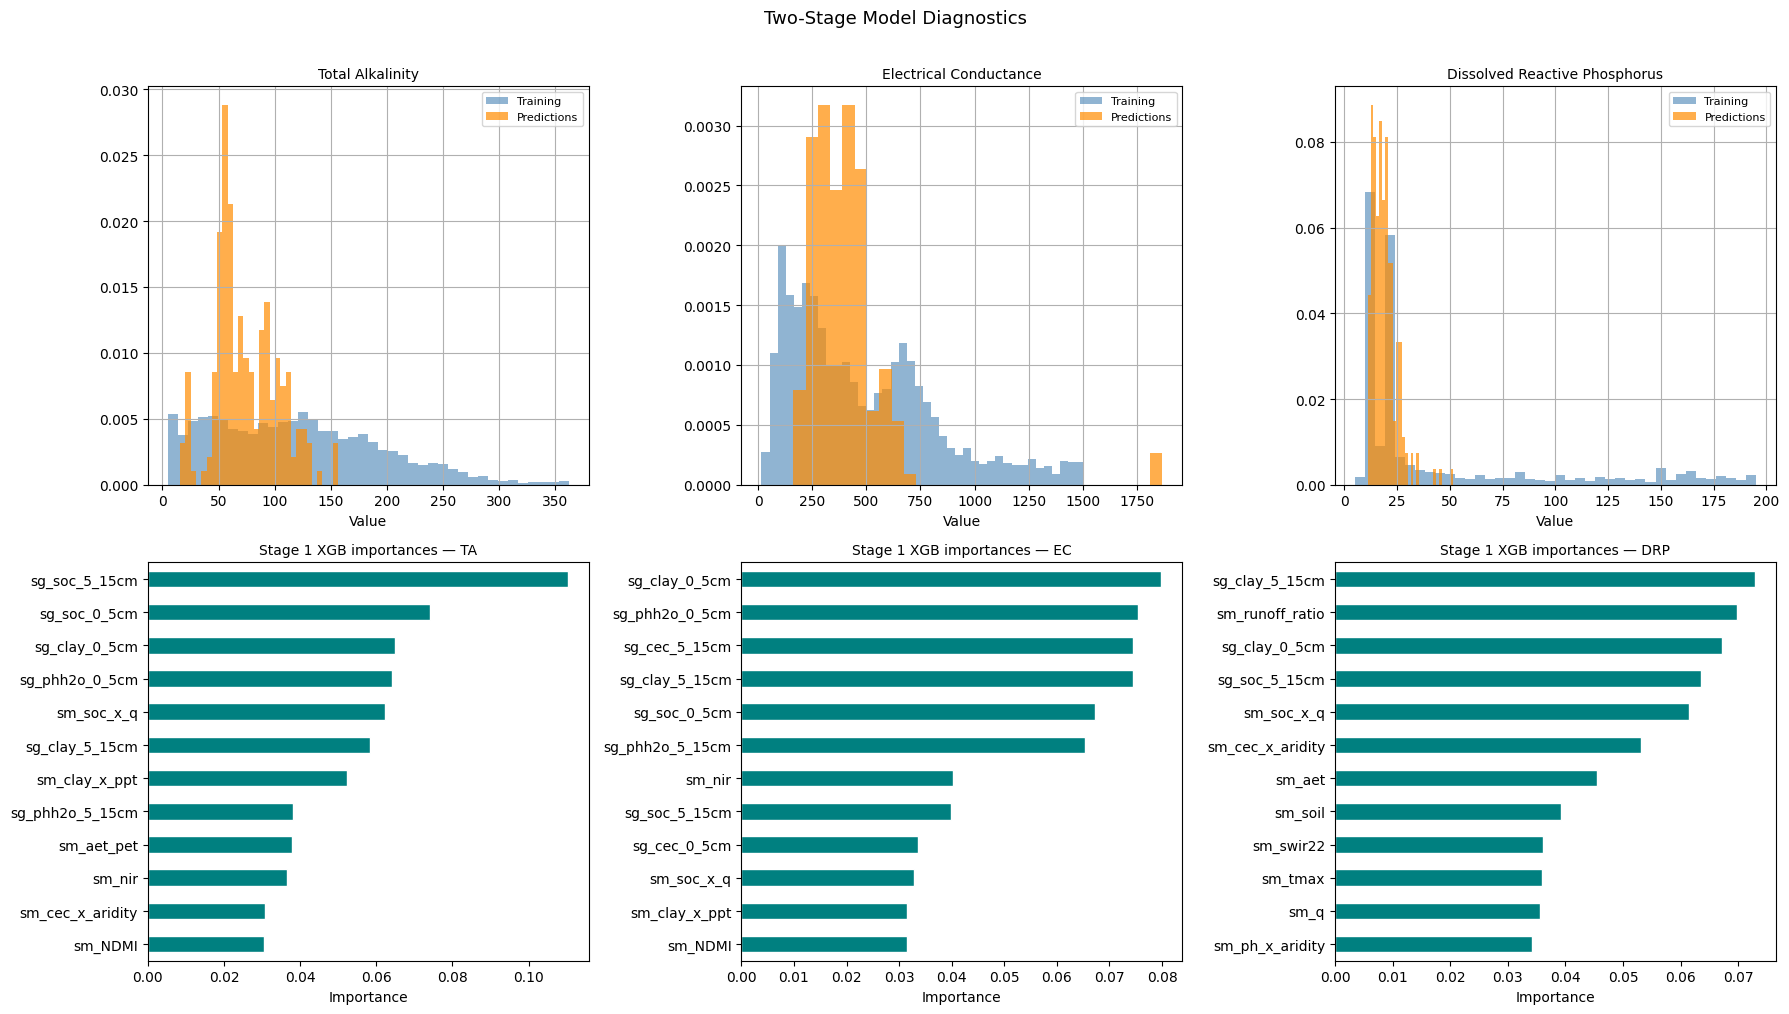


=== Stage 1 CV Summary (geology signal, held-out site means) ===
  TA: R2 = 0.044
  EC: R2 = 0.096
  DRP: R2 = -0.058

=== Stage 2 CV Summary (temporal signal, held-out sites) ===
  TA: R2 = 0.083
  EC: R2 = 0.158
  DRP: R2 = 0.075

=== Final Submission Stats ===
  Total Alkalinity: mean=74.7  std=28.4
  Electrical Conductance: mean=403.5  std=211.9
  Dissolved Reactive Phosphorus: mean=19.0  std=6.0


In [14]:
# ── Diagnostics ────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Row 1: distribution comparison (training vs predictions)
for ax, (t_key, t_col) in zip(axes[0], TARGET_COLS.items()):
    train[t_col].hist(bins=40, ax=ax, alpha=0.6, label='Training', color='steelblue', density=True)
    pd.Series(predictions[t_key]).hist(bins=30, ax=ax, alpha=0.7, label='Predictions', color='darkorange', density=True)
    ax.set_title(t_col, fontsize=10)
    ax.legend(fontsize=8)
    ax.set_xlabel('Value')

# Row 2: Stage 1 feature importances (XGBoost)
for ax, t_key in zip(axes[1], ['TA','EC','DRP']):
    imp_ser = pd.Series(stage1_models[t_key]['xgb'].feature_importances_,
                        index=STAGE1_FEATURES)
    imp_ser.nlargest(12)[::-1].plot(kind='barh', ax=ax, color='teal', edgecolor='white')
    ax.set_title(f'Stage 1 XGB importances — {t_key}', fontsize=10)
    ax.set_xlabel('Importance')

plt.suptitle('Two-Stage Model Diagnostics', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('../Miscellaneous/two_stage_diagnostics.png', dpi=100, bbox_inches='tight')
plt.show()

# Summary table
print('\n=== Stage 1 CV Summary (geology signal, held-out site means) ===')
for k, v in s1_cv_r2.items():
    print(f'  {k}: R2 = {np.mean(v):.3f}')

print('\n=== Stage 2 CV Summary (temporal signal, held-out sites) ===')
for k, v in s2_cv_r2.items():
    print(f'  {k}: R2 = {np.mean(v):.3f}')

print('\n=== Final Submission Stats ===')
for t_key, t_col in TARGET_COLS.items():
    p = predictions[t_key]
    print(f'  {t_col}: mean={p.mean():.1f}  std={p.std():.1f}')